# PySR demo — rediscovering the bulk latent-heat-flux formula

[PySR](https://github.com/MilesCranmer/PySR) does *symbolic regression*: instead of fitting
coefficients to a model you chose, it searches over the space of **equations** and returns a
Pareto front trading accuracy against complexity.

This notebook is a self-contained demo. It first checks the install, then poses a problem with
a known answer so we can grade the result.

**Environment.** In JupyterHub, pick the **`PySR 1.5.10 (L96M2lines)`** kernel. From a shell:

```bash
source /glade/u/apps/opt/miniforge/default/etc/profile.d/conda.sh
conda activate /glade/work/wchapman/conda-envs/L96M2lines
```

One gotcha worth knowing: `juliapkg` locates its Julia project from `CONDA_PREFIX`. Run the env's
python by absolute path without activating — or launch a kernel from JupyterHub's base env — and
the import dies with `PermissionError: /glade/u/apps/jupyterhub/jh-23.11/julia_env`. The
`PySR 1.5.10 (L96M2lines)` kernelspec activates the env in a wrapper script and pins
`PYTHON_JULIAPKG_PROJECT`, so the kernel is immune. In a plain shell, just activate.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pysr
from pysr import PySRRegressor

# First import boots Julia; ~10 s warm, a few minutes if it must precompile.
from pysr.julia_import import jl

print("pysr                  ", pysr.__version__)
print("julia                 ", jl.seval("string(VERSION)"))
print("SymbolicRegression.jl ", jl.seval("string(pkgversion(SymbolicRegression))"))

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


pysr                   1.5.10
julia                  1.12.6
SymbolicRegression.jl  1.11.3


## Plot style

A small shared style so the two figures read as one system: recessive grid and axes, thin marks,
text in neutral ink, identity carried by the mark rather than by colored text. The two accent
colors are a colorblind-safe pair (checked for CVD separation and contrast against the surface).

In [2]:
%matplotlib inline

BLUE  = "#4269D0"   # data / model
AMBER = "#C77B26"   # the selected equation
INK   = "#33322e"   # primary text
MUTED = "#78766f"   # secondary text, reference lines

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.edgecolor": "#c9c7c0",
    "axes.labelcolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e4dd",
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## The problem

Air–sea latent heat flux is conventionally parameterized by a bulk aerodynamic formula:

$$ \mathrm{LH} \;=\; \underbrace{\rho\, L_v\, C_E}_{\textstyle C}\; U \,\bigl(q_s - q_a\bigr) $$

with wind speed $U$, saturation specific humidity at the surface $q_s$, and air specific
humidity $q_a$. With $\rho = 1.2\ \mathrm{kg\,m^{-3}}$, $L_v = 2.5\times10^6\ \mathrm{J\,kg^{-1}}$
and $C_E = 1.3\times10^{-3}$, the lumped constant is $C = 3900$ for humidity in kg/kg — or
$C = 3.9$ with humidity in **g/kg**, which is what we use. That choice is not cosmetic: in kg/kg
the target is a constant of 3900 multiplying a near-cancellation of two numbers around 0.02, and
the search struggles to assemble it. Conditioning the variables to $O(1)$–$O(10)$ is the single
most useful thing you can do for a symbolic regression.

We generate noisy synthetic "observations" and hand PySR **five** candidate predictors — the
three that matter plus two that do not:

| feature | role |
|---|---|
| `U` | wind speed — in the true law |
| `qs`, `qa` | humidities — in the true law |
| `SST` | *redundant*: $q_s$ was derived from it, so it is strongly correlated with a real predictor |
| `junk` | *irrelevant*: pure noise |

A useful method has to recover the functional form **and** discard the two distractors. That is
the part ordinary regression cannot do for you.

In [3]:
rng = np.random.default_rng(42)
n = 400

U   = rng.uniform(2.0, 16.0, n)          # m/s
SST = rng.uniform(295.0, 303.0, n)       # K

# Saturation specific humidity from SST (Tetens / Clausius-Clapeyron approximation, p = 1013 hPa)
Tc  = SST - 273.15
es  = 6.112 * np.exp(17.67 * Tc / (Tc + 243.5))          # hPa
qs  = 1000.0 * 0.622 * es / (1013.0 - 0.378 * es)        # g/kg

RH  = rng.uniform(0.55, 0.95, n)
qa  = RH * qs
junk = rng.normal(0.0, 1.0, n)

C_TRUE = 1.2 * 2.5e6 * 1.3e-3 / 1000.0   # = 3.9  (humidity in g/kg)
LH_clean = C_TRUE * U * (qs - qa)
LH = LH_clean + rng.normal(0.0, 2.0, n)  # ~1.5% observation noise

X = pd.DataFrame({"U": U, "qs": qs, "qa": qa, "SST": SST, "junk": junk})
y = LH

print(f"C_true = {C_TRUE}")
print(f"qs range: {qs.min():.1f} to {qs.max():.1f} g/kg")
print(f"LH range: {LH.min():.1f} to {LH.max():.1f} W/m^2")
X.describe().T[["mean", "std", "min", "max"]].round(4)

C_true = 3.9
qs range: 16.2 to 26.2 g/kg
LH range: 12.2 to 595.7 W/m^2


,mean,std,min,max
U,8.9516,3.9903,2.1031,15.8933
qs,20.8237,2.9541,16.2480,26.2459
qa,15.6890,3.2145,9.7701,24.8473
SST,298.9380,2.3698,295.0099,302.9928
junk,-0.0421,1.0623,-2.9556,2.7107


## Fit

Notes on the settings:

- `parallelism="serial"` because Casper login nodes expose a single core (`nproc` = 1). On a real
  allocation use `parallelism="multithreading"` and set `procs`.
- `deterministic=True` with `random_state` makes the run reproducible; it requires serial mode.
- Only `+ - *` are enabled. Adding operators you don't need enlarges the search space for nothing;
  division is not in the bulk formula, so it is not offered.
- `maxsize=12` caps complexity. The true law needs 7 nodes, so this leaves headroom without
  letting the search wander into baroque expressions.

In [4]:
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*"],
    maxsize=12,
    population_size=50,
    parallelism="serial",
    deterministic=True,
    random_state=0,
    progress=False,
    verbosity=0,
    temp_equation_file=True,
)

t0 = time.time()
model.fit(X, y)
print(f"search wall time: {time.time() - t0:.0f} s")

search wall time: 48 s


## The Pareto front

PySR does not return *an* equation, it returns a front: the best expression found at each
complexity. Reading it is the point of the method — you look for the elbow, the complexity
beyond which extra terms stop buying accuracy.

In [5]:
front = model.equations_[["complexity", "loss", "score", "equation"]].copy()
front.style.format({"loss": "{:.4g}", "score": "{:.3f}"}).hide(axis="index")

complexity,loss,score,equation
1,1.678e+04,0.000,179.03441
3,9049,0.309,U * qs
5,8292,0.044,(qs - qa) * 34.91957
7,4.066,3.810,(qs - qa) * (U * 3.894465)
9,4.037,0.004,(qs - qa) * ((U * 3.9010782) - 0.07139696)


In [6]:
best = model.sympy()
print("selected equation:", best)
print("as latex         :", model.latex())

pred = model.predict(X)
rmse = float(np.sqrt(np.mean((pred - y) ** 2)))
r2 = 1.0 - np.sum((pred - y) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"\nRMSE {rmse:.2f} W/m^2   (noise floor 2.00)")
print(f"R^2  {r2:.5f}")

used = {s for s in X.columns if s in str(best)}
print(f"\nfeatures used    : {sorted(used)}")
print(f"distractors used : {sorted(used & {'SST', 'junk'})} <- want this empty")

selected equation: (-qa + qs)*U*3.894465
as latex         : \left(- qa + qs\right) U 3.89

RMSE 2.02 W/m^2   (noise floor 2.00)
R^2  0.99976

features used    : ['U', 'qa', 'qs']
distractors used : [] <- want this empty


### Grading the recovered constant

If the form is right, the leading coefficient should land on $C = 3.9$. We fit that one number
by least squares against the recovered structure to read it off directly.

In [7]:
# Regress the true structure U*(qs-qa) onto the prediction to expose the effective constant.
struct = U * (qs - qa)
C_hat = float(np.dot(struct, pred) / np.dot(struct, struct))
print(f"C_true      {C_TRUE:8.4f}")
print(f"C_recovered {C_hat:8.4f}")
print(f"error       {100 * abs(C_hat - C_TRUE) / C_TRUE:8.2f} %")

C_true        3.9000
C_recovered   3.8945
error           0.14 %


## Figures

Left, the accuracy/complexity tradeoff, with the selected equation marked. Right, the selected
equation's predictions against the observations, with the 1:1 line for reference.

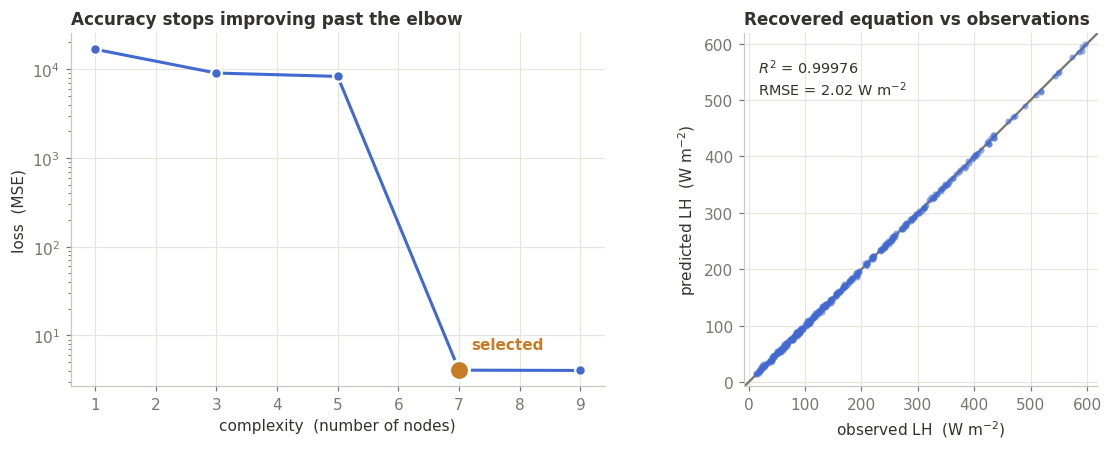

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Pareto front: loss vs complexity -------------------------------------
best_row = model.get_best()          # the row picked by model_selection
sel = int(best_row["complexity"])
sel_loss = float(best_row["loss"])

ax1.plot(front["complexity"], front["loss"], "-o", color=BLUE, lw=2, ms=7,
         mfc=BLUE, mec="white", mew=1.5, zorder=3)
ax1.plot([sel], [sel_loss], "o", color=AMBER, ms=13, mec="white", mew=2, zorder=4)
ax1.annotate("selected", xy=(sel, sel_loss), xytext=(8, 14),
             textcoords="offset points", color=AMBER, fontweight="semibold")
ax1.set_yscale("log")
ax1.set_xlabel("complexity  (number of nodes)")
ax1.set_ylabel("loss  (MSE)")
ax1.set_title("Accuracy stops improving past the elbow", loc="left")
despine(ax1)

# --- Predicted vs observed ------------------------------------------------
lim = [min(y.min(), pred.min()) - 20, max(y.max(), pred.max()) + 20]
ax2.plot(lim, lim, "-", color=MUTED, lw=1.5, zorder=2)
ax2.scatter(y, pred, s=16, color=BLUE, alpha=0.55, linewidths=0, zorder=3)
ax2.set_xlim(lim); ax2.set_ylim(lim); ax2.set_aspect("equal")
ax2.set_xlabel("observed LH  (W m$^{-2}$)")
ax2.set_ylabel("predicted LH  (W m$^{-2}$)")
ax2.set_title("Recovered equation vs observations", loc="left")
ax2.text(0.04, 0.93, f"$R^2$ = {r2:.5f}\nRMSE = {rmse:.2f} W m$^{{-2}}$",
         transform=ax2.transAxes, va="top", color=INK, fontsize=9.5)
despine(ax2)

fig.tight_layout()
plt.show()

## Extrapolation — the reason to bother

A black-box regressor interpolates the training envelope. A recovered *equation* is a physical
statement, so it should hold outside it. Here we test on wind speeds up to 25 m/s, well beyond
the 16 m/s ceiling PySR ever saw.

In [9]:
U_hi = rng.uniform(16.0, 25.0, 150)      # outside the training range
qs_hi = rng.choice(qs, 150)
qa_hi = rng.uniform(0.55, 0.95, 150) * qs_hi
X_hi = pd.DataFrame({
    "U": U_hi, "qs": qs_hi, "qa": qa_hi,
    "SST": rng.uniform(295.0, 303.0, 150), "junk": rng.normal(0.0, 1.0, 150),
})
y_hi = C_TRUE * U_hi * (qs_hi - qa_hi)

pred_hi = model.predict(X_hi)
rmse_hi = float(np.sqrt(np.mean((pred_hi - y_hi) ** 2)))
pct = 100 * rmse_hi / y_hi.std()
print(f"extrapolated RMSE {rmse_hi:.2f} W/m^2  ({pct:.2f}% of signal std)")

extrapolated RMSE 0.68 W/m^2  (0.33% of signal std)


## Takeaways

- PySR recovered the bulk formula's functional form and its coefficient from noisy data, and
  **dropped both distractor features** on its own.
- The output is an equation you can read, differentiate, and carry outside the training range —
  which is what separates it from a fitted black box.
- Cost is the catch: the search is combinatorial. Scale `niterations`, `population_size`, and
  `maxsize` to your budget, and prune the operator set to what the physics can plausibly contain.

### Running it bigger

On a compute node, drop the serial constraint:

```python
model = PySRRegressor(
    niterations=1000,
    parallelism="multithreading",
    procs=os.cpu_count(),   # set explicitly; don't trust the default on a shared node
    ...
)
```

Submit with PBS rather than running on a login node, e.g.
`qsub -l select=1:ncpus=16 -l walltime=02:00:00 -q casper ...`.